<a href="https://colab.research.google.com/github/gamana29/Mobile-Network-Quality-of-Service-Analysis-and-Prediction/blob/main/Mobile_Network_QoS_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile Network QoS Analysis and Prediction Using Machine Learning

## Dataset: SUTD 5G Network Dataset
**File:** `Lvl6_AllRRUOn_Anomaly_label.csv`

This notebook performs:
1. Data loading and inspection
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. 5G QoS parameter analysis
5. Correlation analysis
6. Downlink throughput prediction using regression
7. Network anomaly classification
8. Feature importance analysis
9. Saving trained models

**Student:** B Gayathri Reddy


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
import joblib

plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Upload and Load Dataset

In [2]:
# Run this cell in Google Colab
from google.colab import files
uploaded = files.upload()

# Automatically get the uploaded CSV file name
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df.shape)


Saving Lvl6_AllRRUOn_Anomaly_label.csv to Lvl6_AllRRUOn_Anomaly_label (1).csv
Dataset loaded successfully!
File name: Lvl6_AllRRUOn_Anomaly_label (1).csv
Dataset shape: (2222, 19)


## 3. Display First Five Rows

In [3]:
df.head()

,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 17:48:59.671,628416,17,1350791784,-81.500000,-10.3,36.000000,25.0,13.0,128.0,4.0,486866153,16125,0,0,0,0,0,0
1,2022-10-04 17:49:00.171,628416,17,1350791784,-81.599998,-10.3,35.299999,25.0,13.0,128.0,4.0,486866153,16125,0,0,0,0,0,0
2,2022-10-04 17:49:00.697,628416,17,1350791784,-83.199997,-10.3,33.400002,25.0,14.0,128.0,4.0,486866153,16125,0,0,0,0,0,0
3,2022-10-04 17:49:01.195,628416,17,1350791784,-83.500000,-10.3,34.799999,26.0,14.0,128.0,4.0,358360103,16125,0,0,0,0,0,0
4,2022-10-04 17:49:01.694,628416,17,1350791784,-80.099998,-10.3,36.700001,25.0,14.0,128.0,4.0,358360103,16125,0,0,0,0,0,0


## 4. Dataset Information

In [4]:
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATASET INFORMATION:")
df.info()

COLUMN NAMES:
['Time', 'NR-ARFCN', 'PCI', '_oid', 'RSRP', 'RSRQ', 'SINR', 'PDSCH_MCS', 'PUSCH_MCS', 'PDSCH PRBs', 'PUSCH PRBs', 'throughput_DL', 'C-RNTI', 'Corridor_tag', 'lab_anom', 'lab_bs', 'lab_inf', 'lab_1rr', 'Label']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2222 entries, 0 to 2221
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           2222 non-null   object 
 1   NR-ARFCN       2222 non-null   int64  
 2   PCI            2222 non-null   int64  
 3   _oid           2222 non-null   int64  
 4   RSRP           2222 non-null   float64
 5   RSRQ           2222 non-null   float64
 6   SINR           2222 non-null   float64
 7   PDSCH_MCS      2218 non-null   float64
 8   PUSCH_MCS      2218 non-null   float64
 9   PDSCH PRBs     2218 non-null   float64
 10  PUSCH PRBs     2218 non-null   float64
 11  throughput_DL  2222 non-null   int64  
 12  C-RNTI         2222 non-nu

## 5. Statistical Summary

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
NR-ARFCN,2222.0,6.284160e+05,0.000000e+00,6.284160e+05,6.284160e+05,6.284160e+05,6.284160e+05,6.284160e+05
PCI,2222.0,1.700000e+01,0.000000e+00,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01
_oid,2222.0,1.350792e+09,0.000000e+00,1.350792e+09,1.350792e+09,1.350792e+09,1.350792e+09,1.350792e+09
RSRP,2222.0,-9.189532e+01,1.304620e+01,-1.222000e+02,-1.032000e+02,-8.700000e+01,-8.130000e+01,-7.060000e+01
RSRQ,2222.0,-1.058132e+01,4.771760e-01,-1.370000e+01,-1.060000e+01,-1.040000e+01,-1.030000e+01,-1.020000e+01
SINR,2222.0,2.587187e+01,1.108086e+01,1.400000e+00,1.512500e+01,3.110000e+01,3.480000e+01,3.950000e+01
PDSCH_MCS,2218.0,2.089675e+01,4.985290e+00,5.000000e+00,1.800000e+01,2.300000e+01,2.500000e+01,2.800000e+01
PUSCH_MCS,2218.0,1.304509e+01,2.522742e+00,5.000000e+00,1.200000e+01,1.400000e+01,1.500000e+01,1.600000e+01
PDSCH PRBs,2218.0,1.277913e+02,4.588151e+00,4.000000e+00,1.280000e+02,1.280000e+02,1.280000e+02,1.290000e+02
PUSCH PRBs,2218.0,4.311993e+00,8.648139e-01,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,2.500000e+01


## 6. Check Missing Values

Time             0
NR-ARFCN         0
PCI              0
_oid             0
RSRP             0
RSRQ             0
SINR             0
PDSCH_MCS        4
PUSCH_MCS        4
PDSCH PRBs       4
PUSCH PRBs       4
throughput_DL    0
C-RNTI           0
Corridor_tag     0
lab_anom         0
lab_bs           0
lab_inf          0
lab_1rr          0
Label            0
dtype: int64


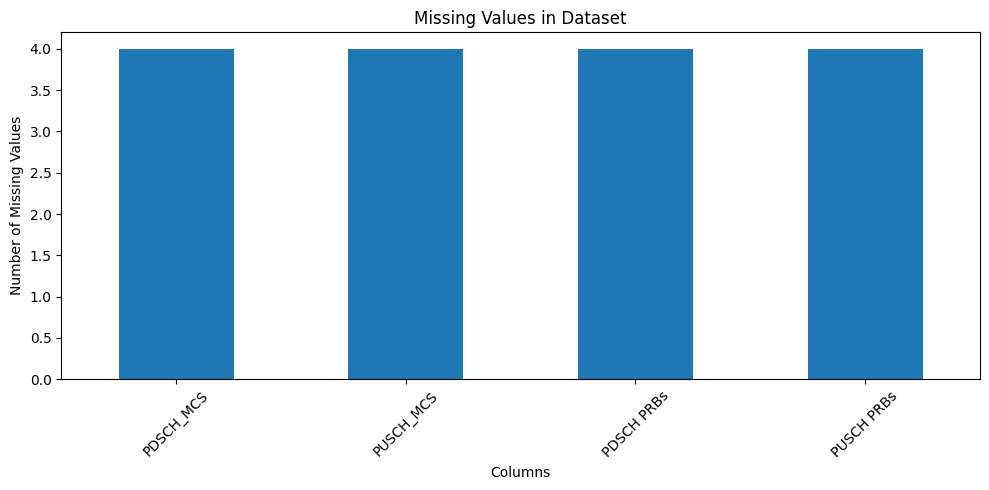

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

plt.figure(figsize=(10, 5))
missing_values[missing_values > 0].plot(kind="bar")
plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Data Cleaning

In [7]:
# Remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Convert Time column to datetime
df["Time"] = pd.to_datetime(df["Time"])

# Extract useful time features
df["Hour"] = df["Time"].dt.hour
df["Minute"] = df["Time"].dt.minute

# Fill missing numerical values using median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Duplicates removed:", duplicates_before)
print("Final dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicates removed: 0
Final dataset shape: (2222, 21)

Missing values after cleaning:
Time             0
NR-ARFCN         0
PCI              0
_oid             0
RSRP             0
RSRQ             0
SINR             0
PDSCH_MCS        0
PUSCH_MCS        0
PDSCH PRBs       0
PUSCH PRBs       0
throughput_DL    0
C-RNTI           0
Corridor_tag     0
lab_anom         0
lab_bs           0
lab_inf          0
lab_1rr          0
Label            0
Hour             0
Minute           0
dtype: int64


## 8. Important 5G QoS Parameters

In [8]:
qos_columns = [
    "RSRP",
    "RSRQ",
    "SINR",
    "PDSCH_MCS",
    "PUSCH_MCS",
    "PDSCH PRBs",
    "PUSCH PRBs",
    "throughput_DL"
]

df[qos_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
RSRP,2222.0,-9.189532e+01,1.304620e+01,-1.222000e+02,-1.032000e+02,-87.0,-8.130000e+01,-7.060000e+01
RSRQ,2222.0,-1.058132e+01,4.771760e-01,-1.370000e+01,-1.060000e+01,-10.4,-1.030000e+01,-1.020000e+01
SINR,2222.0,2.587187e+01,1.108086e+01,1.400000e+00,1.512500e+01,31.1,3.480000e+01,3.950000e+01
PDSCH_MCS,2222.0,2.090054e+01,4.981597e+00,5.000000e+00,1.800000e+01,23.0,2.500000e+01,2.800000e+01
PUSCH_MCS,2222.0,1.304680e+01,2.520794e+00,5.000000e+00,1.200000e+01,14.0,1.500000e+01,1.600000e+01
PDSCH PRBs,2222.0,1.277916e+02,4.584026e+00,4.000000e+00,1.280000e+02,128.0,1.280000e+02,1.290000e+02
PUSCH PRBs,2222.0,4.311431e+00,8.641360e-01,4.000000e+00,4.000000e+00,4.0,4.000000e+00,2.500000e+01
throughput_DL,2222.0,2.362280e+08,1.133594e+08,3.411354e+07,1.206282e+08,289733806.0,3.297009e+08,4.868662e+08


## 9. RSRP Distribution

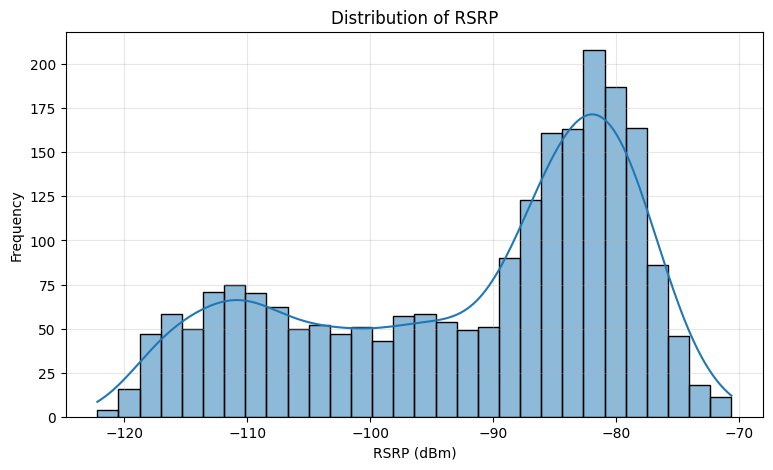

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(df["RSRP"], bins=30, kde=True)
plt.title("Distribution of RSRP")
plt.xlabel("RSRP (dBm)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


## 10. RSRQ Distribution

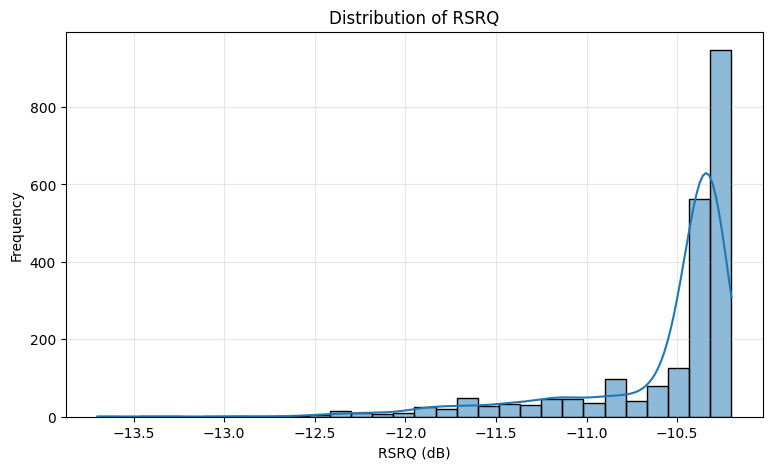

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df["RSRQ"], bins=30, kde=True)
plt.title("Distribution of RSRQ")
plt.xlabel("RSRQ (dB)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


## 11. SINR Distribution

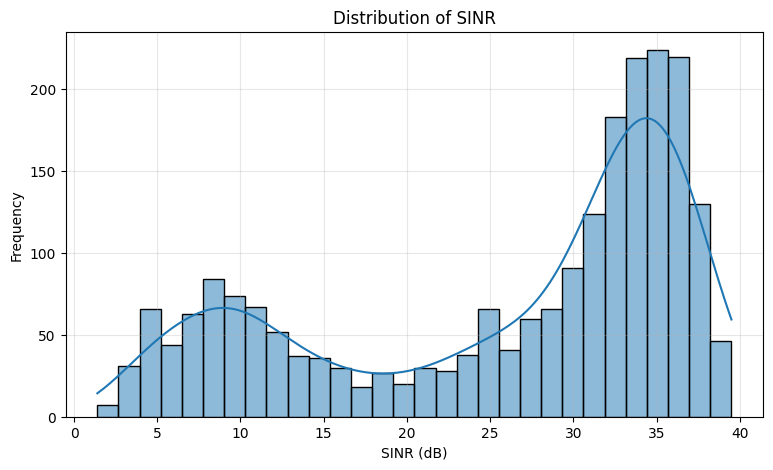

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(df["SINR"], bins=30, kde=True)
plt.title("Distribution of SINR")
plt.xlabel("SINR (dB)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


## 12. Downlink Throughput Distribution

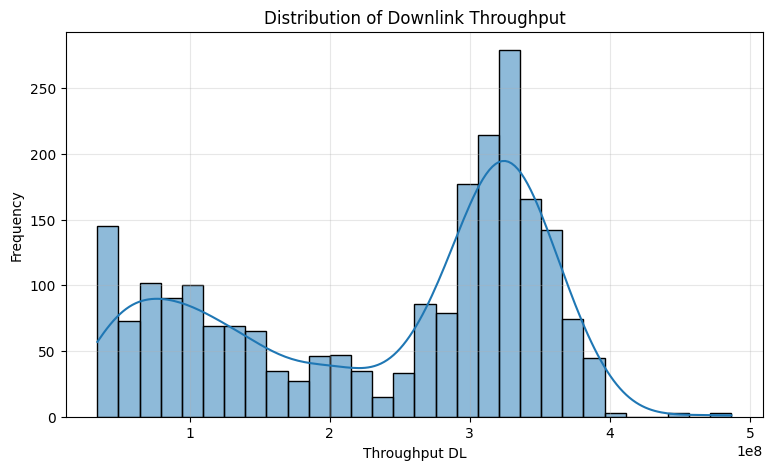

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(df["throughput_DL"], bins=30, kde=True)
plt.title("Distribution of Downlink Throughput")
plt.xlabel("Throughput DL")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


## 13. Box Plot of Important QoS Parameters

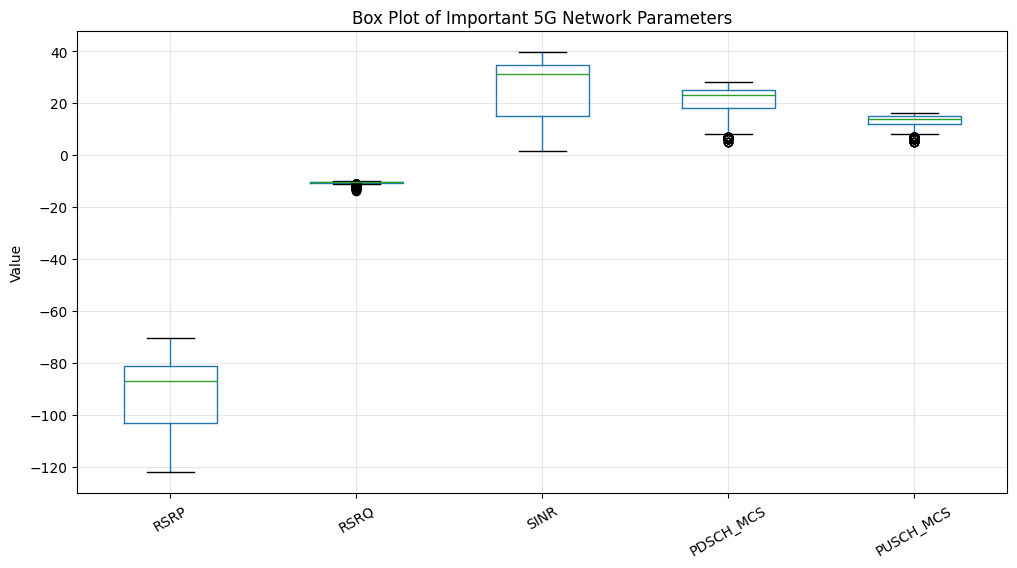

In [13]:
plot_columns = ["RSRP", "RSRQ", "SINR", "PDSCH_MCS", "PUSCH_MCS"]

plt.figure(figsize=(12, 6))
df[plot_columns].boxplot()
plt.title("Box Plot of Important 5G Network Parameters")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.show()


## 14. Correlation Heatmap

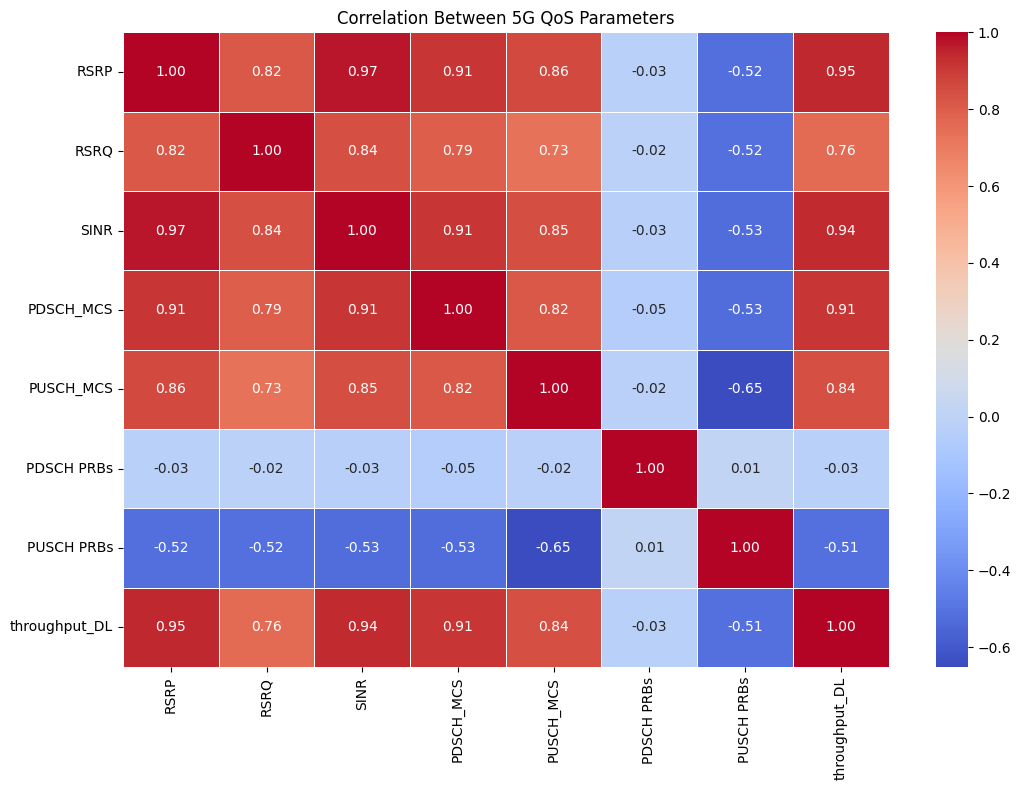

In [14]:
correlation_columns = [
    "RSRP", "RSRQ", "SINR",
    "PDSCH_MCS", "PUSCH_MCS",
    "PDSCH PRBs", "PUSCH PRBs",
    "throughput_DL"
]

plt.figure(figsize=(11, 8))
sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Between 5G QoS Parameters")
plt.tight_layout()
plt.show()


## 15. SINR vs Downlink Throughput

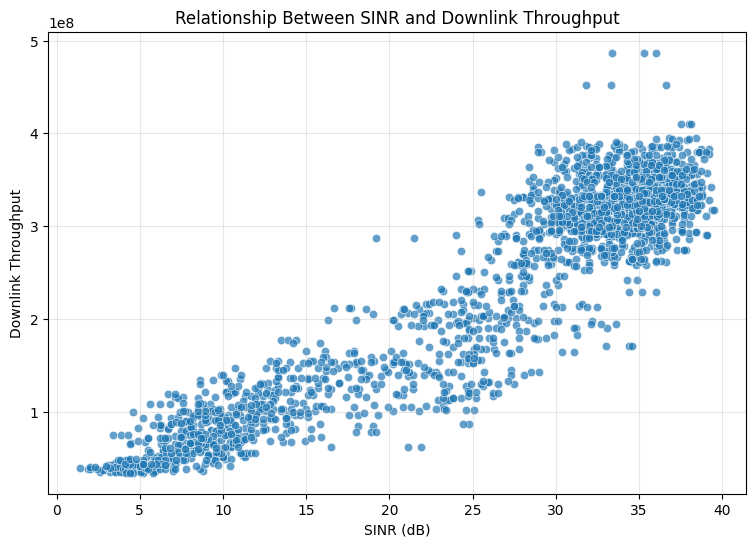

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="SINR", y="throughput_DL", alpha=0.7)
plt.title("Relationship Between SINR and Downlink Throughput")
plt.xlabel("SINR (dB)")
plt.ylabel("Downlink Throughput")
plt.grid(alpha=0.3)
plt.show()


## 16. RSRP vs Downlink Throughput

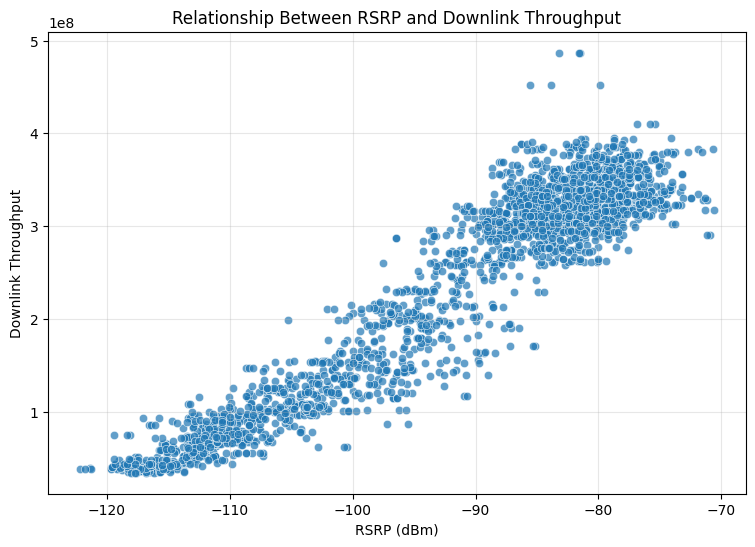

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="RSRP", y="throughput_DL", alpha=0.7)
plt.title("Relationship Between RSRP and Downlink Throughput")
plt.xlabel("RSRP (dBm)")
plt.ylabel("Downlink Throughput")
plt.grid(alpha=0.3)
plt.show()


## 17. RSRQ vs Downlink Throughput

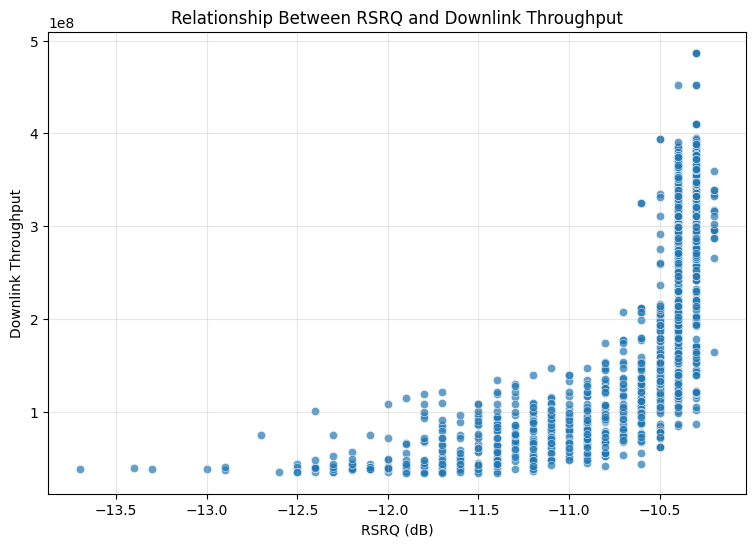

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="RSRQ", y="throughput_DL", alpha=0.7)
plt.title("Relationship Between RSRQ and Downlink Throughput")
plt.xlabel("RSRQ (dB)")
plt.ylabel("Downlink Throughput")
plt.grid(alpha=0.3)
plt.show()


## 18. PRB Allocation vs Downlink Throughput

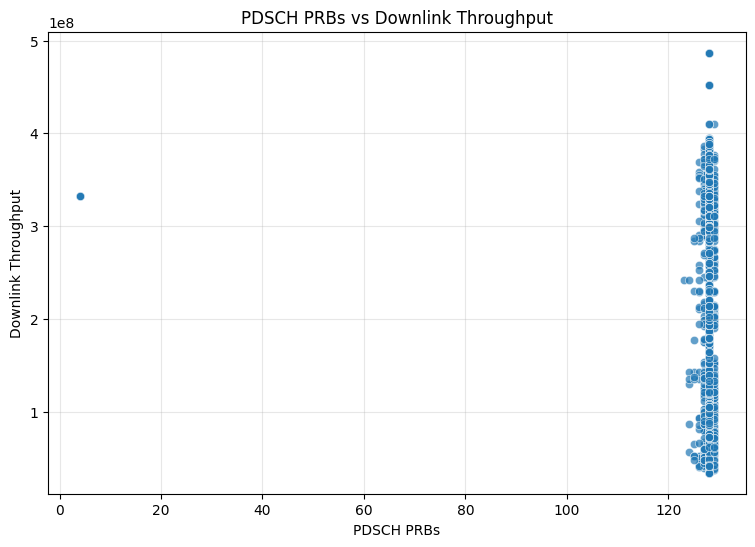

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="PDSCH PRBs", y="throughput_DL", alpha=0.7)
plt.title("PDSCH PRBs vs Downlink Throughput")
plt.xlabel("PDSCH PRBs")
plt.ylabel("Downlink Throughput")
plt.grid(alpha=0.3)
plt.show()


## 19. Anomaly Label Distribution

Anomaly label counts:
lab_anom
1    1112
0    1110
Name: count, dtype: int64


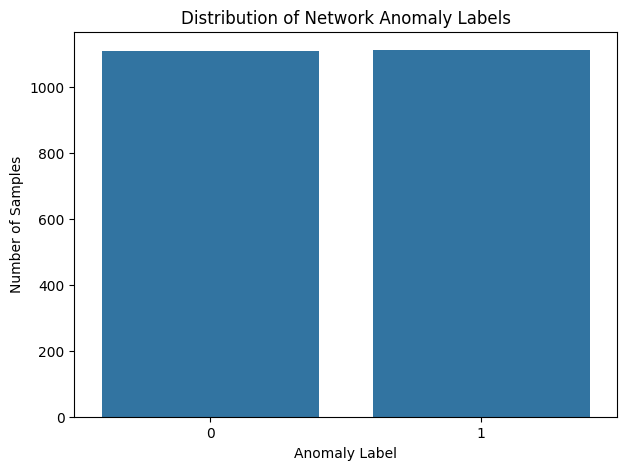

In [19]:
print("Anomaly label counts:")
print(df["lab_anom"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="lab_anom")
plt.title("Distribution of Network Anomaly Labels")
plt.xlabel("Anomaly Label")
plt.ylabel("Number of Samples")
plt.show()


# PART A: DOWNLINK THROUGHPUT PREDICTION

The objective is to predict `throughput_DL` using radio and resource-allocation parameters.


## 20. Feature Selection for Regression

In [20]:
regression_features = [
    "RSRP",
    "RSRQ",
    "SINR",
    "PDSCH_MCS",
    "PUSCH_MCS",
    "PDSCH PRBs",
    "PUSCH PRBs"
]

X_reg = df[regression_features]
y_reg = df["throughput_DL"]

print("Input features:")
print(regression_features)
print("\nTarget: throughput_DL")
print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)


Input features:
['RSRP', 'RSRQ', 'SINR', 'PDSCH_MCS', 'PUSCH_MCS', 'PDSCH PRBs', 'PUSCH PRBs']

Target: throughput_DL
X shape: (2222, 7)
y shape: (2222,)


## 21. Train-Test Split for Regression

In [21]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])


Training samples: 1777
Testing samples: 445


## 22. Train Regression Models

In [22]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

regression_results = {}

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    r2 = r2_score(y_test_reg, predictions)

    regression_results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    print(f"\n{name}")
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2 Score:", round(r2, 4))



Linear Regression
MAE: 23496518.1911
RMSE: 30325432.9779
R2 Score: 0.928

Random Forest
MAE: 18509686.6427
RMSE: 25907145.3167
R2 Score: 0.9475

Gradient Boosting
MAE: 18555004.4319
RMSE: 25351037.4972
R2 Score: 0.9497


## 23. Regression Model Comparison

In [23]:
regression_results_df = pd.DataFrame(regression_results).T
regression_results_df


,MAE,RMSE,R2 Score
Linear Regression,2.349652e+07,3.032543e+07,0.928009
Random Forest,1.850969e+07,2.590715e+07,0.947458
Gradient Boosting,1.855500e+07,2.535104e+07,0.949690


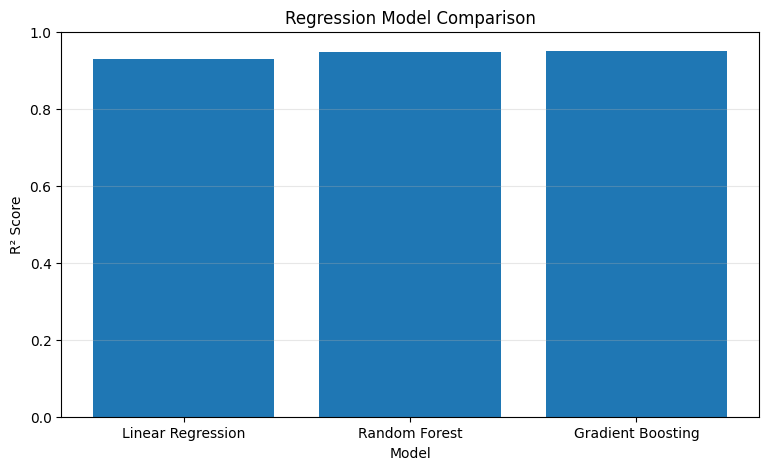

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(regression_results_df.index, regression_results_df["R2 Score"])
plt.title("Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 24. Select Best Regression Model

In [25]:
best_regression_model_name = regression_results_df["R2 Score"].idxmax()
best_regression_model = regression_models[best_regression_model_name]

print("Best Regression Model:", best_regression_model_name)

best_reg_predictions = best_regression_model.predict(X_test_reg)


Best Regression Model: Gradient Boosting


## 25. Actual vs Predicted Throughput

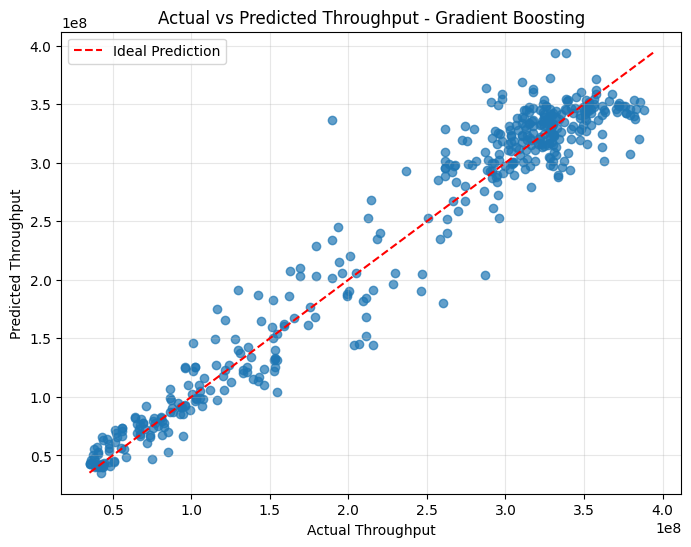

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_reg, best_reg_predictions, alpha=0.7)

min_value = min(y_test_reg.min(), best_reg_predictions.min())
max_value = max(y_test_reg.max(), best_reg_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Throughput")
plt.ylabel("Predicted Throughput")
plt.title(f"Actual vs Predicted Throughput - {best_regression_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 26. Regression Feature Importance

      Feature  Importance
0        RSRP    0.840807
2        SINR    0.099550
3   PDSCH_MCS    0.034595
4   PUSCH_MCS    0.015198
1        RSRQ    0.004584
5  PDSCH PRBs    0.003965
6  PUSCH PRBs    0.001301


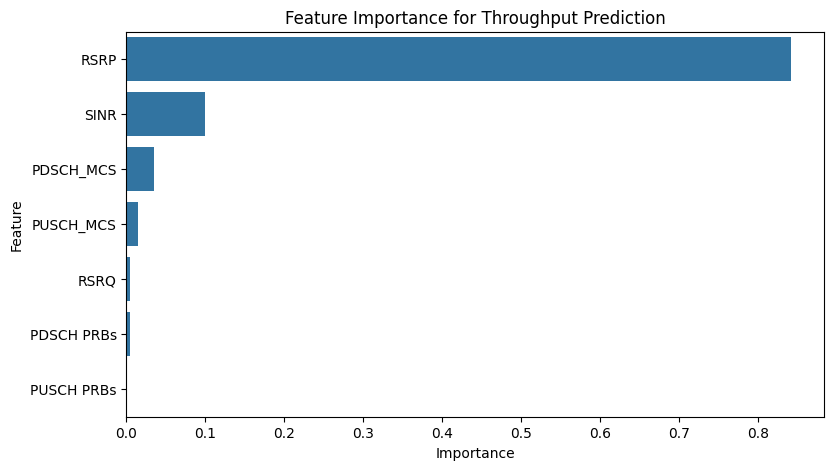

In [27]:
# Tree-based feature importance
feature_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

feature_model.fit(X_train_reg, y_train_reg)

importance_df = pd.DataFrame({
    "Feature": regression_features,
    "Importance": feature_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance for Throughput Prediction")
plt.show()


# PART B: NETWORK ANOMALY CLASSIFICATION

The objective is to predict `lab_anom` using 5G network QoS parameters.


## 27. Check Anomaly Classes

In [28]:
print(df["lab_anom"].value_counts())
print("\nPercentage distribution:")
print((df["lab_anom"].value_counts(normalize=True) * 100).round(2))


lab_anom
1    1112
0    1110
Name: count, dtype: int64

Percentage distribution:
lab_anom
1    50.05
0    49.95
Name: proportion, dtype: float64


## 28. Feature Selection for Classification

In [29]:
classification_features = [
    "RSRP",
    "RSRQ",
    "SINR",
    "PDSCH_MCS",
    "PUSCH_MCS",
    "PDSCH PRBs",
    "PUSCH PRBs",
    "throughput_DL"
]

X_cls = df[classification_features]
y_cls = df["lab_anom"]

print("Classification features:")
print(classification_features)
print("\nTarget: lab_anom")


Classification features:
['RSRP', 'RSRQ', 'SINR', 'PDSCH_MCS', 'PUSCH_MCS', 'PDSCH PRBs', 'PUSCH PRBs', 'throughput_DL']

Target: lab_anom


## 29. Train-Test Split for Classification

In [30]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])


Training samples: 1777
Testing samples: 445


## 30. Train Classification Models

In [31]:
classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        random_state=42
    )
}

classification_results = {}
trained_classification_models = {}

for name, model in classification_models.items():
    model.fit(X_train_cls, y_train_cls)
    predictions = model.predict(X_test_cls)

    accuracy = accuracy_score(y_test_cls, predictions)
    precision = precision_score(y_test_cls, predictions, zero_division=0)
    recall = recall_score(y_test_cls, predictions, zero_division=0)
    f1 = f1_score(y_test_cls, predictions, zero_division=0)

    classification_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    trained_classification_models[name] = model

classification_results_df = pd.DataFrame(classification_results).T
classification_results_df


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.910112,0.955224,0.860987,0.905660
Decision Tree,0.905618,0.950249,0.856502,0.900943
Random Forest,0.898876,0.940594,0.852018,0.894118
Gradient Boosting,0.919101,0.960591,0.874439,0.915493


## 31. Classification Model Comparison

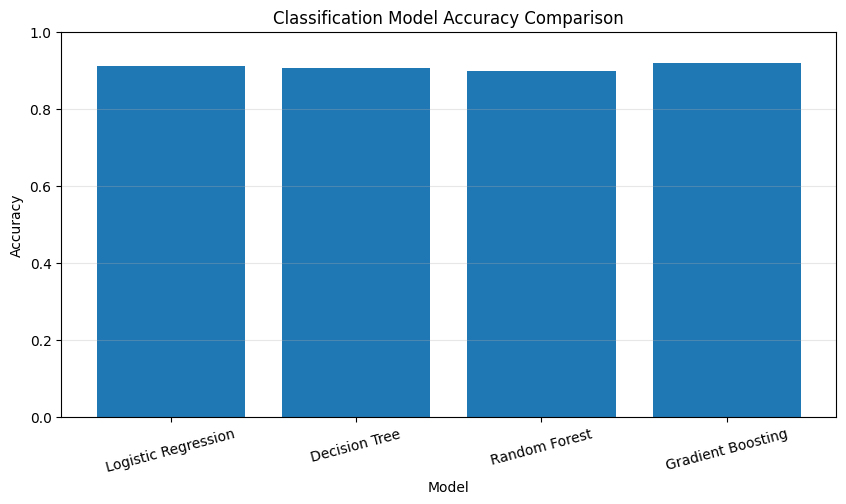

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(
    classification_results_df.index,
    classification_results_df["Accuracy"]
)

plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 32. Select Best Classification Model

In [33]:
best_classification_model_name = classification_results_df["F1 Score"].idxmax()
best_classification_model = trained_classification_models[best_classification_model_name]

print("Best Classification Model:", best_classification_model_name)

best_cls_predictions = best_classification_model.predict(X_test_cls)

print("\nClassification Report:")
print(classification_report(y_test_cls, best_cls_predictions, zero_division=0))


Best Classification Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       222
           1       0.96      0.87      0.92       223

    accuracy                           0.92       445
   macro avg       0.92      0.92      0.92       445
weighted avg       0.92      0.92      0.92       445



## 33. Confusion Matrix

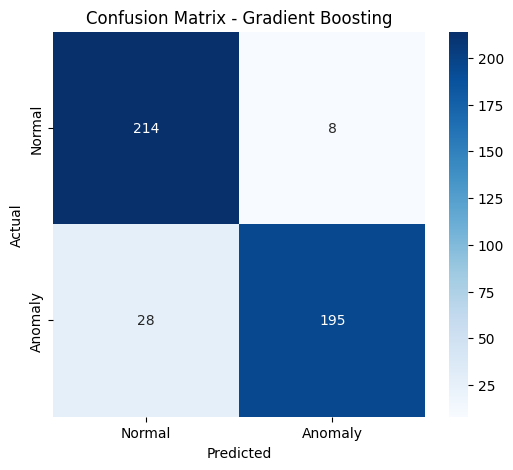

In [34]:
cm = confusion_matrix(y_test_cls, best_cls_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_classification_model_name}")
plt.show()


## 34. Classification Feature Importance

         Feature  Importance
7  throughput_DL    0.285175
0           RSRP    0.236709
2           SINR    0.201509
3      PDSCH_MCS    0.108598
4      PUSCH_MCS    0.099765
1           RSRQ    0.043915
5     PDSCH PRBs    0.013212
6     PUSCH PRBs    0.011117


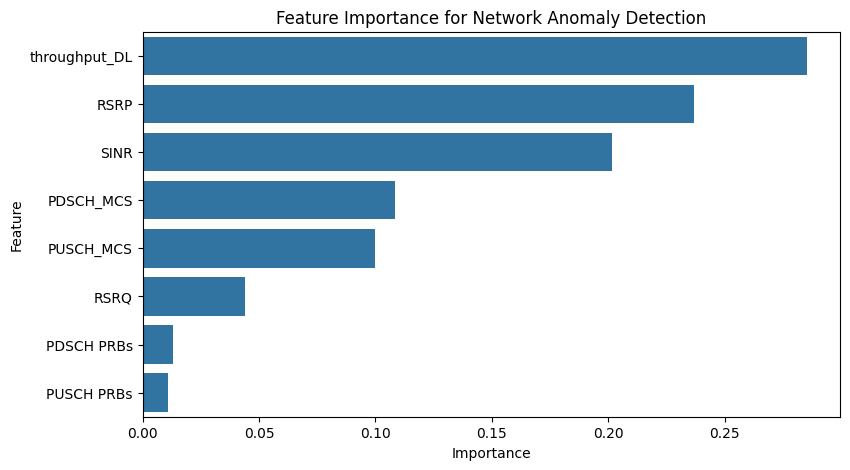

In [35]:
classification_feature_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

classification_feature_model.fit(X_train_cls, y_train_cls)

classification_importance_df = pd.DataFrame({
    "Feature": classification_features,
    "Importance": classification_feature_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(classification_importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=classification_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Network Anomaly Detection")
plt.show()


## 35. Save Trained Models

In [36]:
# Save best throughput prediction model
joblib.dump(
    best_regression_model,
    "best_throughput_prediction_model.pkl"
)

# Save best anomaly classification model
joblib.dump(
    best_classification_model,
    "best_anomaly_detection_model.pkl"
)

# Save feature lists
joblib.dump(
    regression_features,
    "regression_features.pkl"
)

joblib.dump(
    classification_features,
    "classification_features.pkl"
)

print("Models saved successfully!")
print("Files created:")
print("- best_throughput_prediction_model.pkl")
print("- best_anomaly_detection_model.pkl")
print("- regression_features.pkl")
print("- classification_features.pkl")


Models saved successfully!
Files created:
- best_throughput_prediction_model.pkl
- best_anomaly_detection_model.pkl
- regression_features.pkl
- classification_features.pkl


## 36. Download Saved Models (Google Colab)

In [38]:
from google.colab import files

files.download("best_throughput_prediction_model.pkl")
files.download("best_anomaly_detection_model.pkl")
files.download("regression_features.pkl")
files.download("classification_features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 37. Final Results Summary

After running all cells, summarize your results below.

### Project Outcomes
- Analyzed real 5G network QoS parameters.
- Studied RSRP, RSRQ, SINR, MCS, PRB allocation and downlink throughput.
- Compared multiple regression models for throughput prediction.
- Compared multiple classification models for anomaly detection.
- Identified important features influencing network performance.
- Saved the best trained machine learning models.

### Final Conclusion Template

> This project analyzed real-world 5G mobile network measurements to study Quality of Service performance. Radio parameters such as RSRP, RSRQ, SINR, modulation and coding schemes, and physical resource block allocation were examined. Machine learning models were developed for downlink throughput prediction and network anomaly detection. The best-performing models were selected based on R² score for regression and F1 score for classification. Feature importance analysis identified the network parameters that most strongly influence mobile network performance and QoS.
